In [195]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [184]:
data = pd.read_excel('water_leak_issue.xlsx')
data

,Region,Description,Problem,Street Name,Street Type
0,West,Pipe burst,Blockage,Birch,Terrace
1,South,Water pooling,Blockage,Oak,Terrace
2,North,Continuous leakage,Blockage,Elm,Court
3,East,Low pressure,Blockage,Maple,Lane
4,East,Water pooling,Leakage,Cedar,Drive
5,Central,Continuous leakage,Unknown,Birch,Street
6,East,Low pressure,Unknown,Cedar,Street
7,Central,Continuous leakage,Pressure drop,Birch,Terrace
8,Central,Pipe burst,Contamination,Spruce,Lane
9,North,Continuous leakage,Leakage,Chestnut,Way


In [185]:
label_encoders = {}
for col in ["Region", "Description", "Problem", "Street Name", "Street Type"]:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le


In [186]:
X = data.drop(columns=["Region","Problem"])
y = data["Description"]

In [187]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [188]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [189]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [190]:
y_pred = model.predict(X_test)

In [191]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Model Accuracy: 0.90

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2
           3       0.67      1.00      0.80         2
           4       1.00      0.67      0.80         3

    accuracy                           0.90        10
   macro avg       0.92      0.92      0.90        10
weighted avg       0.93      0.90      0.90        10


Confusion Matrix:
[[3 0 0 0]
 [0 2 0 0]
 [0 0 2 0]
 [0 0 1 2]]


In [182]:
importances = model.feature_importances_
feature_names = X.columns
print("\nFeature Importances:")
for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.4f}")


Feature Importances:
Description: 0.6162
Street Name: 0.2103
Street Type: 0.1735


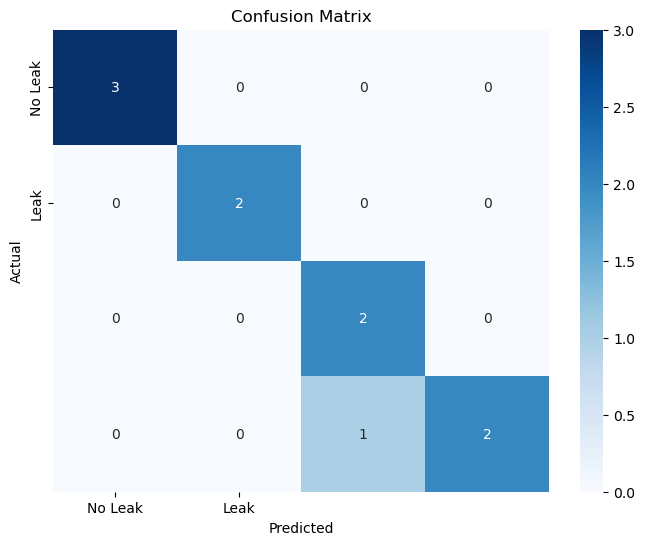

In [196]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Leak', 'Leak'], yticklabels=['No Leak', 'Leak'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

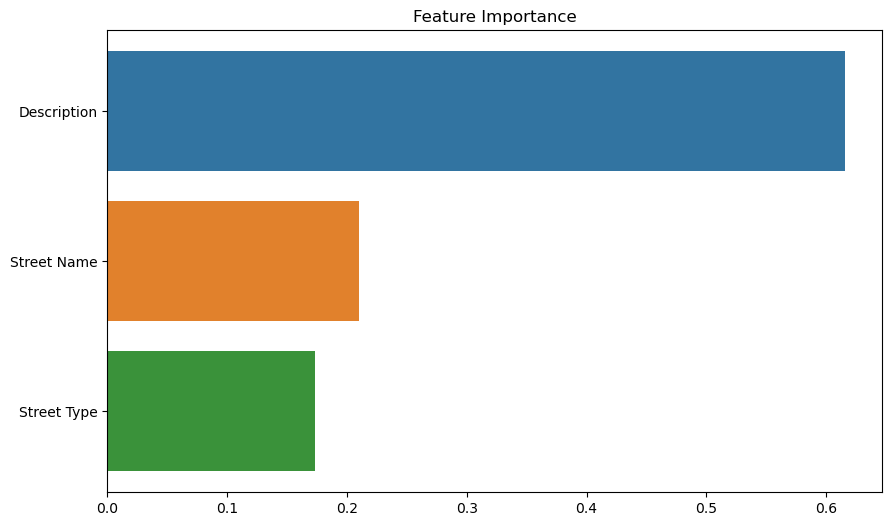

In [200]:
feature_importances = model.feature_importances_
features = X.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=features)
plt.title('Feature Importance')
plt.show()